FileNotFoundError: [Errno 2] No such file or directory: '/home1/kunkim/personalization/output/lora-sd21base-n1'

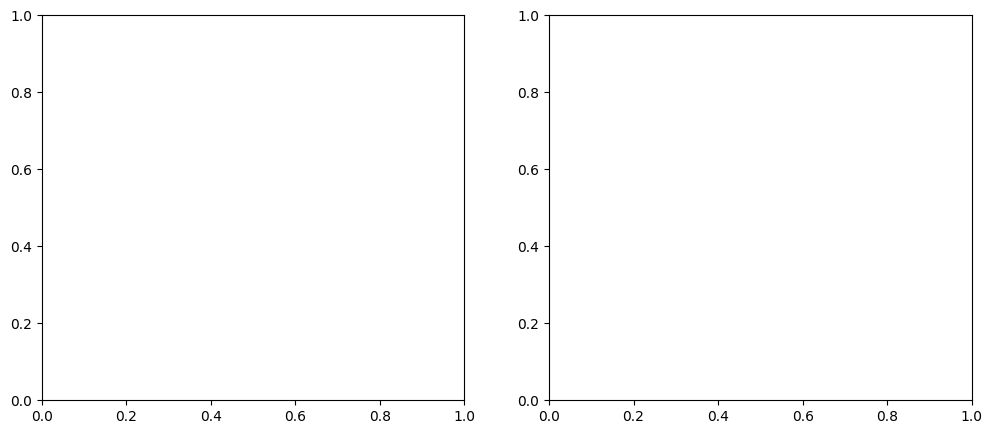

In [1]:
import os

import matplotlib.pyplot as plt


def read_metrics(path):
    metrics = list(filter(lambda x: x.endswith(".csv"), os.listdir(path)))

    def _key(x):
        return int(x.split("_")[1].split(".")[0].replace("ckpt", ""))

    metrics.sort(key=_key)
    print(metrics)

    clips = {}
    vqas = {}
    clip_is = {}
    clip_i_us = {}
    for metric in metrics:
        step = metric.split("_")[1].split(".")[0]
        step = int(step.replace("ckpt", ""))

        clip = 0.0
        vqa = 0.0
        clip_i = 0.0
        clip_i_u = 0.0
        with open(f"{path}/{metric}", "r") as f:
            lines = f.readlines()
            # seed, clip, vqa, clip_i, clip_i_u, dino, dino_us
            for line in lines[1:]:
                values = line.split(",")
                clip += float(values[1])
                vqa += float(values[2])
                clip_i += float(values[3])
                clip_i_u += float(values[4])
        clips[step] = clip / len(lines[1:])
        vqas[step] = vqa / len(lines[1:])
        clip_is[step] = clip_i / len(lines[1:])
        clip_i_us[step] = clip_i_u / len(lines[1:])
    return clips, vqas, clip_is, clip_i_us


def plot_metrics(exp, ax, unseen=False):
    clips, vqas, clip_is, clip_i_us = read_metrics(exp)
    if "tb" in exp:
        clips = {k: v * 2.5 for k, v in clips.items()}
    label = os.path.basename(exp)
    if unseen:
        ax.plot(vqas.values(), clip_i_us.values(), label=label)
    else:
        ax.plot(vqas.values(), clip_is.values(), label=label)

    # y_metric = clip_i_us if unseen else clip_is
    # for i in (0, -1):
    #     iter = list(vqas.keys())[i]
    #     x = vqas[iter]
    #     y = y_metric[iter]
    #     ax.annotate(
    #         str(iter), (x, y), textcoords="offset points", xytext=(0, 5), ha="center",
    #         arrowprops=dict(arrowstyle="->", facecolor="black")
    #     )


paths = [
    "/home1/kunkim/personalization/output/lora-sd21base-n1",
    "/home1/kunkim/personalization/output/cd-sd21base-n1",
    "/home1/kunkim/personalization/output/cd-sd21base-n1-low-lr",
    "../output/tb-sd21base-n1-legacy",
    # "../output/tb-sd21base-n1-default",
    # "../output/tb-sd21base-n1-ti_style",
    # "../output/tb-sd21base-n1-cd_style",
    "../output/tb-sd21base-n1-repro",
    "../output/tb-sd21base-n1-iccv-adaptive",
    "../output/tb-sd21base-n1-rand_init",
    "../output/tb-sd21base-n1-rand_init2",
    "../output/tb-sd21base-n1-no_sample",
]

fig, axs = plt.subplots(1, 2)
fig.set_size_inches(12, 5)

for i, exp in enumerate(paths):
    plot_metrics(exp, axs[0])
axs[0].legend()
axs[0].set_xlabel("VQA")
axs[0].set_ylabel("CLIP-I")
axs[0].set_xlim([0.3, 1.0])
axs[0].set_ylim([0.65, 0.9])

for i, exp in enumerate(paths):
    plot_metrics(exp, axs[1], unseen=True)
axs[1].legend()
axs[1].set_xlabel("VQA")
axs[1].set_ylabel("CLIP-I (unseen)")
axs[1].set_xlim([0.3, 0.9])
axs[1].set_ylim([0.65, 0.9])

In [2]:
# fig.savefig("metrics.png")
fig.savefig("metrics.svg")  # can be edited in Inkscape
# fig.savefig("metrics.pdf")

In [1]:
import numpy as np

with open("../tmp/face-results.txt", "r") as f:
    lines = f.readlines()


tb = []
tb_fail = []
neti = []
neti_fail = []
cd = []
cd_fail = []
disen = []
disen_fail = []

for line in lines:
    line = line.strip()
    method = line.split("/")[1]
    distance = float(line.split(": ")[-1])
    if method == "eval-face":
        tb.append(distance)
    elif method == "eval-face-cd":
        cd.append(distance)
    elif method == "eval-face-neti":
        neti.append(distance)
    elif method == "eval-face-disen":
        disen.append(distance)

# if one of the items are failed (distance == 100.0), remove corresponding items
indices = []
for i in range(len(tb)):
    if tb[i] != 100.0 and cd[i] != 100.0 and neti[i] != 100.0 and disen[i] != 100.0:
        indices.append(i)
tb = [tb[i] for i in indices]
cd = [cd[i] for i in indices]
neti = [neti[i] for i in indices]
disen = [disen[i] for i in indices]

print(f"TextBoost: {1 - np.mean(tb):.3f}")
print(f"CD: {1 - np.mean(cd):.3f}")
print(f"Neti: {1 - np.mean(neti):.3f}")
print(f"Disen: {1 - np.mean(disen):.3f}")

FileNotFoundError: [Errno 2] No such file or directory: '../tmp/face-results.txt'

In [4]:
import numpy as np


def read(path):
    with open(path, "r") as f:
        lines = f.readlines()

    metrics = {}
    headers = lines[0].strip().split(",")[1:]  # skip the first column (checkpoint)
    for line in lines[1:]:
        splits = line.strip().split(",")
        checkpoint = splits[0]
        if checkpoint not in metrics:
            metrics[checkpoint] = {}
            for h in headers:
                metrics[checkpoint][h] = []
        for j, v in enumerate(splits[1:]):
            metrics[checkpoint][headers[j]].append(float(v))
    for checkpoint in metrics:
        for h in headers:
            metrics[checkpoint][h] = np.mean(metrics[checkpoint][h])
    return metrics


# f = "/local2/kunkim/textboost-dev/output/tb-sana1.5-1.6b-n1-r0/metric.csv"
# f = "/local2/kunkim/textboost-dev/output/tb-sana1.5-1.6b-n1/metric.csv"
# f = "/local2/kunkim/textboost-dev/output/tb-sana1.5-1.6b-n1-pp/metric.csv"
f = "/local2/kunkim/textboost-dev/output/lora-sana1.5-1.6b-n1-r2/metric.csv"

metrics = read(f)
print(metrics)
for checkpoint in metrics:
    print(f"Checkpoint: {checkpoint}")
    for key, value in metrics[checkpoint].items():
        if key in ("vqa", "dino_unseen"):
            print(f"{key}: {value:.3f}")

{'500': {'seed': np.float64(1.5), 'clip': np.float64(0.0), 'vqa': np.float64(0.7820601314306259), 'clip_i': np.float64(0.0), 'clip_i_unseen': np.float64(0.0), 'dino': np.float64(0.7113059312105179), 'dino_unseen': np.float64(0.5907536149024963)}, '400': {'seed': np.float64(1.5), 'clip': np.float64(0.0), 'vqa': np.float64(0.7928756475448608), 'clip_i': np.float64(0.0), 'clip_i_unseen': np.float64(0.0), 'dino': np.float64(0.6764093637466431), 'dino_unseen': np.float64(0.5744038075208664)}, '300': {'seed': np.float64(1.5), 'clip': np.float64(0.0), 'vqa': np.float64(0.8061367869377136), 'clip_i': np.float64(0.0), 'clip_i_unseen': np.float64(0.0), 'dino': np.float64(0.6098885983228683), 'dino_unseen': np.float64(0.516418993473053)}, '200': {'seed': np.float64(1.5), 'clip': np.float64(0.0), 'vqa': np.float64(0.8187134563922882), 'clip_i': np.float64(0.0), 'clip_i_unseen': np.float64(0.0), 'dino': np.float64(0.5767722874879837), 'dino_unseen': np.float64(0.5034933686256409)}}
Checkpoint: 500
